# 02. Seleccion Optima de Caracteristicas Multimodales y Reduccion de Dimensionalidad

Este cuaderno implementa el protocolo formal de seleccion de caracteristicas y optimizacion dimensional a partir de las 52 variables candidatas oficiales certificadas en el Cuaderno 01.

Aspectos metodologicos clave del proceso:
- Marco normativo de gobernanza: Directrices Fed SR 11-7 (Model Risk Management) y estandares regulatorios EBA / Basilea III sobre parsimonia y estabilidad explicativa.
- Fase 2 (Sondaje Aleatorio no lineal / Random Probes): Inyeccion de variables de ruido blanco sinteticas U(0,1) y N(0,1) para fijar el umbral critico empirico de ruido en CatBoost GPU (mejor modelo en el momento de hacer la selección), podando variables sin poder predictivo incremental.
- Fase 3 (Poda algoritmica de colinealidad de Spearman): Evaluacion no parametrica par a par (|rho| >= 0.75) sobre las 37 variables supervivientes, aplicando reglas de precedencia contable e importancia relativa.
- Fase 4 (Consolidacion del vector canonico): Certificacion del espacio optimo final de 21 variables predictivas multimodales y persistencia de datasets depurados.


In [7]:
# Modulo de referencia: Entregable/src/features/feature_selection_random_probes.py
import os
import sys
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Resolucion determinista de rutas relativas
ROOT_DIR = Path.cwd().resolve()
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

DATA_DIR = ROOT_DIR / "data" / "processed" / "sec_dataset"
FIGURES_DIR = ROOT_DIR / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Rutas de artefactos oficiales
PARQUET_CLEAN_PATH = DATA_DIR / "v2_sec_financials_pivoted_clean.parquet"
V2_PIVOTED_PATH = DATA_DIR / "v2.1_master_financials_dataset.parquet"
if not V2_PIVOTED_PATH.exists():
    V2_PIVOTED_PATH = DATA_DIR / "v2_sec_financials_pivoted.parquet"

FEATURE_SELECTION_REPORT_PATH = DATA_DIR / "feature_selection_report.json"
CORR_PRE_PATH = DATA_DIR / "correlation_matrix_37_features.csv"
CORR_OPT_PATH = DATA_DIR / "correlation_matrix_21_features.csv"

# Semilla determinista global
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Estilo corporativo visual Arial
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

print(f"Directorio raiz: {ROOT_DIR}")
print(f"Directorio de datos: {DATA_DIR}")
print(f"Directorio de figuras: {FIGURES_DIR}")
print(f"Dataset Parquet base: {V2_PIVOTED_PATH} (Existe: {V2_PIVOTED_PATH.exists()})")


Directorio raiz: E:\TFM data science\Entregable
Directorio de datos: E:\TFM data science\Entregable\data\processed\sec_dataset
Directorio de figuras: E:\TFM data science\Entregable\reports\figures
Dataset Parquet base: E:\TFM data science\Entregable\data\processed\sec_dataset\v2.1_master_financials_dataset.parquet (Existe: True)


## 1. Ingesta del Panel Contable y Censo de las 52 Variables Candidatas Oficiales

Carga del panel contable multimodal depurado (393,331 observaciones longitudinales) y verificacion del inventario de 52 variables candidatas oficiales.

Criterios metodologicos de la cohorte:
- Base de datos censal: Registros de estados financieros trimestrales (10-Q) y anuales (10-K) de emisores ante la SEC (2009-2026).
- Descarte previo en Fase 1: Exclusion de 56 campos de metadatos administrativos, variables con fuga prospectiva de target, colinealidades de GMM y ventanas redundantes de prensa NLP.
- Distribucion taxonomica: 31 variables contables de balance y resultados, 3 variables bursatiles y estructurales (Merton KMV), 10 variables macroeconomicas FRED y GMM, y 8 variables de sentimiento mediatico FinBERT.


In [8]:
# Modulo de referencia: Entregable/src/features/feature_selection_random_probes.py
# Modulo de referencia: Entregable/src/data/quality_audit.py
print(f"Cargando dataset maestro desde {V2_PIVOTED_PATH}...")
con = duckdb.connect()
df_master = con.execute(f"SELECT * FROM '{V2_PIVOTED_PATH}';").df()
con.close()

print(f"- Observaciones totales cargadas: {len(df_master):,}")
print(f"- Columnas crudas disponibles:     {len(df_master.columns)}")

if "news_sentiment_avg" not in df_master.columns and "nlp_sentiment_decayed_30d" in df_master.columns:
    df_master["news_sentiment_avg"] = df_master["nlp_sentiment_decayed_30d"].copy()

# Fase 1: Filtro Heuristico (Identico a Notebook 01 y quality_audit.py)
all_cols = df_master.columns.tolist()
meta_cols = ['adsh', 'cik', 'company_name', 'ticker', 'sic', 'form_type', 'period_date', 'filed_date', 'fy', 'filed_year']
target_cols = [c for c in all_cols if c.startswith('target_') or c.startswith('is_distress_event')]
gmm_dummies = ['macro_regime_label', 'macro_regime_name', 'corp_archetype_label', 'corp_archetype_name']
gmm_collinear = ['macro_regime_neutral_prob', 'corp_archetype_prob_3']
network_cols = ['network_pagerank', 'network_betweenness', 'network_degree', 'network_community_id', 'cluster_distress_infection_rate', 'is_network_imputed']
nlp_90d = ['news_count_90d', 'nlp_sentiment_decayed_90d', 'nlp_distress_topic_intensity_decayed_90d', 'distress_news_count_90d']
join_dups = [c for c in all_cols if c.endswith('_1') and not c.startswith('corp_archetype_prob_') and not c.startswith('is_distress_event_')]

all_dropped_phase1 = list(dict.fromkeys(meta_cols + target_cols + gmm_dummies + gmm_collinear + network_cols + nlp_90d + join_dups))
candidate_52_features = [c for c in all_cols if c not in all_dropped_phase1]

if "news_sentiment_avg" not in candidate_52_features and len(candidate_52_features) == 51:
    candidate_52_features.append("news_sentiment_avg")

print(f"\nVariables descartadas en Fase 1: {len(all_dropped_phase1)}")
print(f"Variables candidatas para Fase 2 (Random Probes): {len(candidate_52_features)}")
assert len(candidate_52_features) == 52, f"Error: Se esperaban 52 candidatas, se obtuvieron {len(candidate_52_features)}"

# Desglose de las 52 variables candidatas por pilar
pilar_contable = [c for c in candidate_52_features if c.startswith("tag_") or c in ["pub_lag_days"]]
pilar_mercado = [c for c in candidate_52_features if c in ["merton_distance_to_default", "stock_price_close", "market_cap"]]
pilar_macro = [c for c in candidate_52_features if c.startswith("macro_") or c.startswith("corp_archetype_prob_")]
pilar_nlp = [c for c in candidate_52_features if c.startswith("news_") or c.startswith("nlp_") or c.startswith("distress_") or c.startswith("media_") or c.startswith("is_media_silent_") or c in ["market_news_sentiment_mean"]]

print(f"  * Pilar Contable SEC EDGAR:            {len(pilar_contable)} variables")
print(f"  * Pilar Mercado bursatil y Merton KMV: {len(pilar_mercado)} variables")
print(f"  * Pilar Macro FRED + GMM:              {len(pilar_macro)} variables")
print(f"  * Pilar Prensa Financiera NLP:         {len(pilar_nlp)} variables")
print(f"  * TOTAL CANDIDATAS OFICIALES:          {len(candidate_52_features)} variables")


Cargando dataset maestro desde E:\TFM data science\Entregable\data\processed\sec_dataset\v2.1_master_financials_dataset.parquet...
- Observaciones totales cargadas: 393,331
- Columnas crudas disponibles:     107

Variables descartadas en Fase 1: 56
Variables candidatas para Fase 2 (Random Probes): 52
  * Pilar Contable SEC EDGAR:            19 variables
  * Pilar Mercado bursatil y Merton KMV: 3 variables
  * Pilar Macro FRED + GMM:              11 variables
  * Pilar Prensa Financiera NLP:         19 variables
  * TOTAL CANDIDATAS OFICIALES:          52 variables


## 2. Fase 2: Sondaje Aleatorio en CatBoost GPU (Random Probes)

Implementacion del protocolo de Random Probes para discriminar variables que aporten igual o menos pdoer predictivo que una variable aleatoria

- Inyeccion de ruido blanco ortogonal: Generacion de sondas sinteticas de distribucion uniforme U(0,1) y normal N(0,1) sin relacion causal con el riesgo de quiebra.
- Estimador regularizado no lineal: Ajuste de CatBoost GPU con 300 arboles, profundidad 6 y tasa de aprendizaje 0.05 sobre el panel multimodal.
- Umbral critico de descarte (tau_ruido): Se define como el maximo de importancia porcentual alcanzado por las dos sondas de ruido sintetico.

ENTRENAMIENTO DE CATBOOST GPU PARA CALCULO DE FEATURE IMPORTANCE CON RANDOM PROBES
0:	learn: 0.5895685	total: 4.92ms	remaining: 1.47s
100:	learn: 0.1204313	total: 470ms	remaining: 925ms
200:	learn: 0.1162642	total: 933ms	remaining: 459ms
299:	learn: 0.1135214	total: 1.39s	remaining: 0us

RESULTADOS FORMALES DEL TEST DE SONDAJE ALEATORIO (RANDOM PROBES):
- Importancia predictiva sonda uniforme U(0,1): 0.000000%
- Importancia predictiva sonda normal N(0,1):   0.007965%
=> UMBRAL CRITICO EMPIRICO DE RUIDO TAU_RUIDO:   0.007965%
Variables que superan el umbral de ruido (> 0.007965%): 37
Variables eliminadas por ruido estocastico (<= 0.007965%): 15


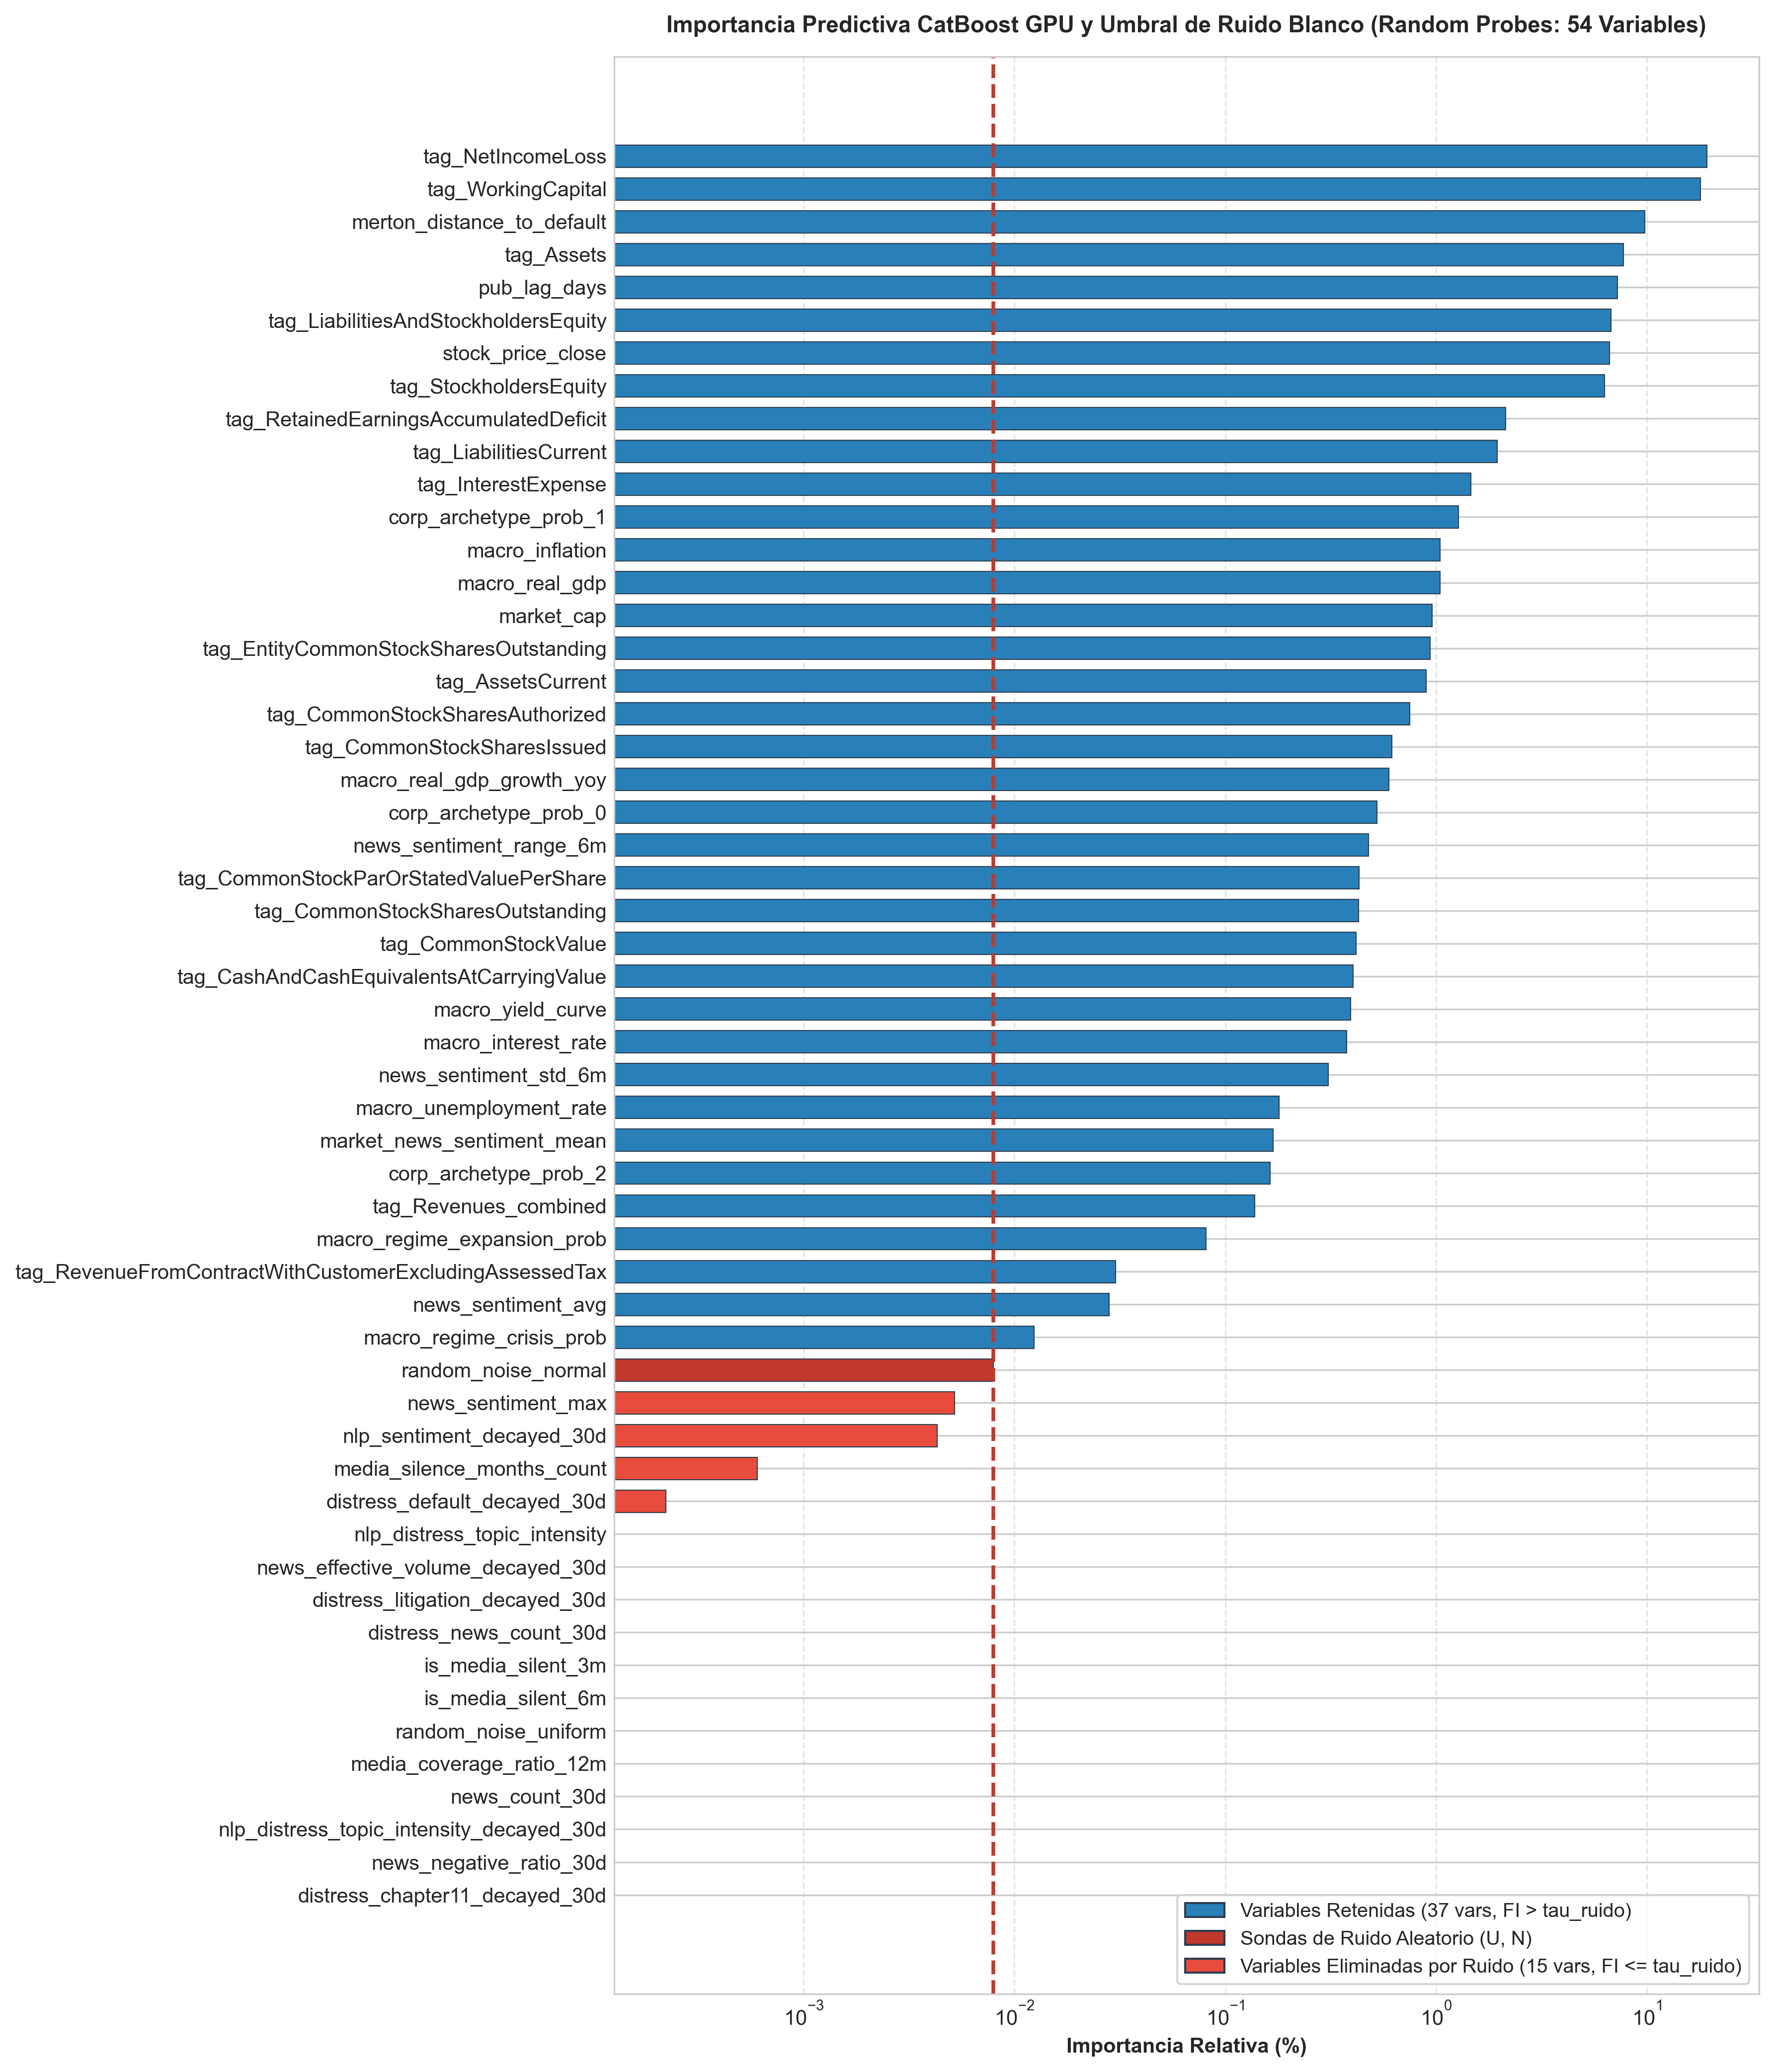

Figura guardada en: E:\TFM data science\Entregable\reports\figures\feat_random_probes_importance.png


In [9]:
# Modulo de referencia: Entregable/src/features/feature_selection_random_probes.py
# Inyeccion de sondas aleatorias de ruido blanco
np.random.seed(RANDOM_SEED)
df_master['random_noise_uniform'] = np.random.uniform(0.0, 1.0, size=len(df_master)).astype(np.float32)
df_master['random_noise_normal'] = np.random.normal(0.0, 1.0, size=len(df_master)).astype(np.float32)

all_probes_features = candidate_52_features + ['random_noise_uniform', 'random_noise_normal']

X_probes = df_master[all_probes_features].copy()
for col in X_probes.select_dtypes(include=[np.number]).columns:
    col_med = X_probes[col].median()
    X_probes[col] = X_probes[col].fillna(col_med if pd.notna(col_med) else 0.0)

y_probes = df_master['target_bankrupt_12m'].values

print("=" * 85)
print("ENTRENAMIENTO DE CATBOOST GPU PARA CALCULO DE FEATURE IMPORTANCE CON RANDOM PROBES")
print("=" * 85)

cb_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    task_type='GPU',
    verbose=100,
    random_seed=RANDOM_SEED
)
cb_model.fit(X_probes, y_probes)

# Extraccion de importancia porcentual
importances = cb_model.get_feature_importance()
fi_df = pd.DataFrame({
    'feature': all_probes_features,
    'importance': importances
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

# Determinacion de tau_ruido
noise_u = fi_df.loc[fi_df['feature'] == 'random_noise_uniform', 'importance'].values[0]
noise_n = fi_df.loc[fi_df['feature'] == 'random_noise_normal', 'importance'].values[0]
tau_noise = max(noise_u, noise_n)

print("\n" + "=" * 85)
print("RESULTADOS FORMALES DEL TEST DE SONDAJE ALEATORIO (RANDOM PROBES):")
print("=" * 85)
print(f"- Importancia predictiva sonda uniforme U(0,1): {noise_u:.6f}%")
print(f"- Importancia predictiva sonda normal N(0,1):   {noise_n:.6f}%")
print(f"=> UMBRAL CRITICO EMPIRICO DE RUIDO TAU_RUIDO:   {tau_noise:.6f}%")
print("=" * 85)

kept_features_rp = fi_df[
    (~fi_df['feature'].isin(['random_noise_uniform', 'random_noise_normal'])) &
    (fi_df['importance'] > tau_noise)
]['feature'].tolist()

dropped_features_rp = fi_df[
    (~fi_df['feature'].isin(['random_noise_uniform', 'random_noise_normal'])) &
    (fi_df['importance'] <= tau_noise)
]

print(f"Variables que superan el umbral de ruido (> {tau_noise:.6f}%): {len(kept_features_rp)}")
print(f"Variables eliminadas por ruido estocastico (<= {tau_noise:.6f}%): {len(dropped_features_rp)}")

# 2.2 Visualizacion Grafica Exhaustiva de TODAS las Variables (54 en Total)
fig_rp, ax_rp = plt.subplots(figsize=(12, 14), dpi=300)

plot_df = fi_df.sort_values(by='importance', ascending=True).copy()
bar_colors = []
for f, imp in zip(plot_df['feature'], plot_df['importance']):
    if f.startswith('random_noise'):
        bar_colors.append('#c0392b')  # Sondas de control en rojo oscuro
    elif imp > tau_noise:
        bar_colors.append('#2980b9')  # Variables retenidas en azul acero
    else:
        bar_colors.append('#e74c3c')  # Variables descartadas en rojo claro / salmon

bars = ax_rp.barh(plot_df['feature'], plot_df['importance'], color=bar_colors, height=0.68, edgecolor='#2c3e50', linewidth=0.5)

# Linea vertical de corte de ruido blanco
ax_rp.axvline(tau_noise, color='#c0392b', linestyle='--', linewidth=1.8, label=f'Umbral de Ruido Blanco (tau_ruido = {tau_noise:.4f}%)')

# Anotacion y formato
ax_rp.set_title("Importancia Predictiva CatBoost GPU y Umbral de Ruido Blanco (Random Probes: 54 Variables)", fontsize=11, fontweight="bold", pad=12)
ax_rp.set_xlabel("Importancia Relativa (%)", fontsize=10, fontweight="bold")
ax_rp.set_xscale('log')  # Escala logarítmica para visualizar simultáneamente variables dominantes y la región de corte
ax_rp.grid(True, linestyle="--", alpha=0.5, axis='x')

# Leyenda explicativa personalizada
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2980b9', edgecolor='#2c3e50', label=f'Variables Retenidas ({len(kept_features_rp)} vars, FI > tau_ruido)'),
    Patch(facecolor='#c0392b', edgecolor='#2c3e50', label=f'Sondas de Ruido Aleatorio (U, N)'),
    Patch(facecolor='#e74c3c', edgecolor='#2c3e50', label=f'Variables Eliminadas por Ruido ({len(dropped_features_rp)} vars, FI <= tau_ruido)')
]
ax_rp.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=9.5)

plt.tight_layout()
fig_rp_path = FIGURES_DIR / "feat_random_probes_importance.png"
fig_rp.savefig(fig_rp_path, dpi=300)
plt.show()
print(f"Figura guardada en: {fig_rp_path}")


## 3. Fase 3: Poda Algoritmica de Colinealidad de Spearman (|rho| >= 0.75)

Mecanica del algoritmo de descarte iterativo:
- Umbral Limite maximo tolerable fijado en |rho| < 0.75
- Resolucion de redundancias contables: Aplicacion de precedencia financiera (e.g. Activos frente a Pasivo+Patrimonio, Working Capital frente a Pasivo Corriente, Inflacion frente a PIB).
- Regla de desempate empirico: En pares sin precedencia analitica fija, se conserva la caracteristica con mayor importancia relativa en CatBoost.


Dimension matriz de correlacion pre-poda (variables retenidas en Fase 2): (37, 37)


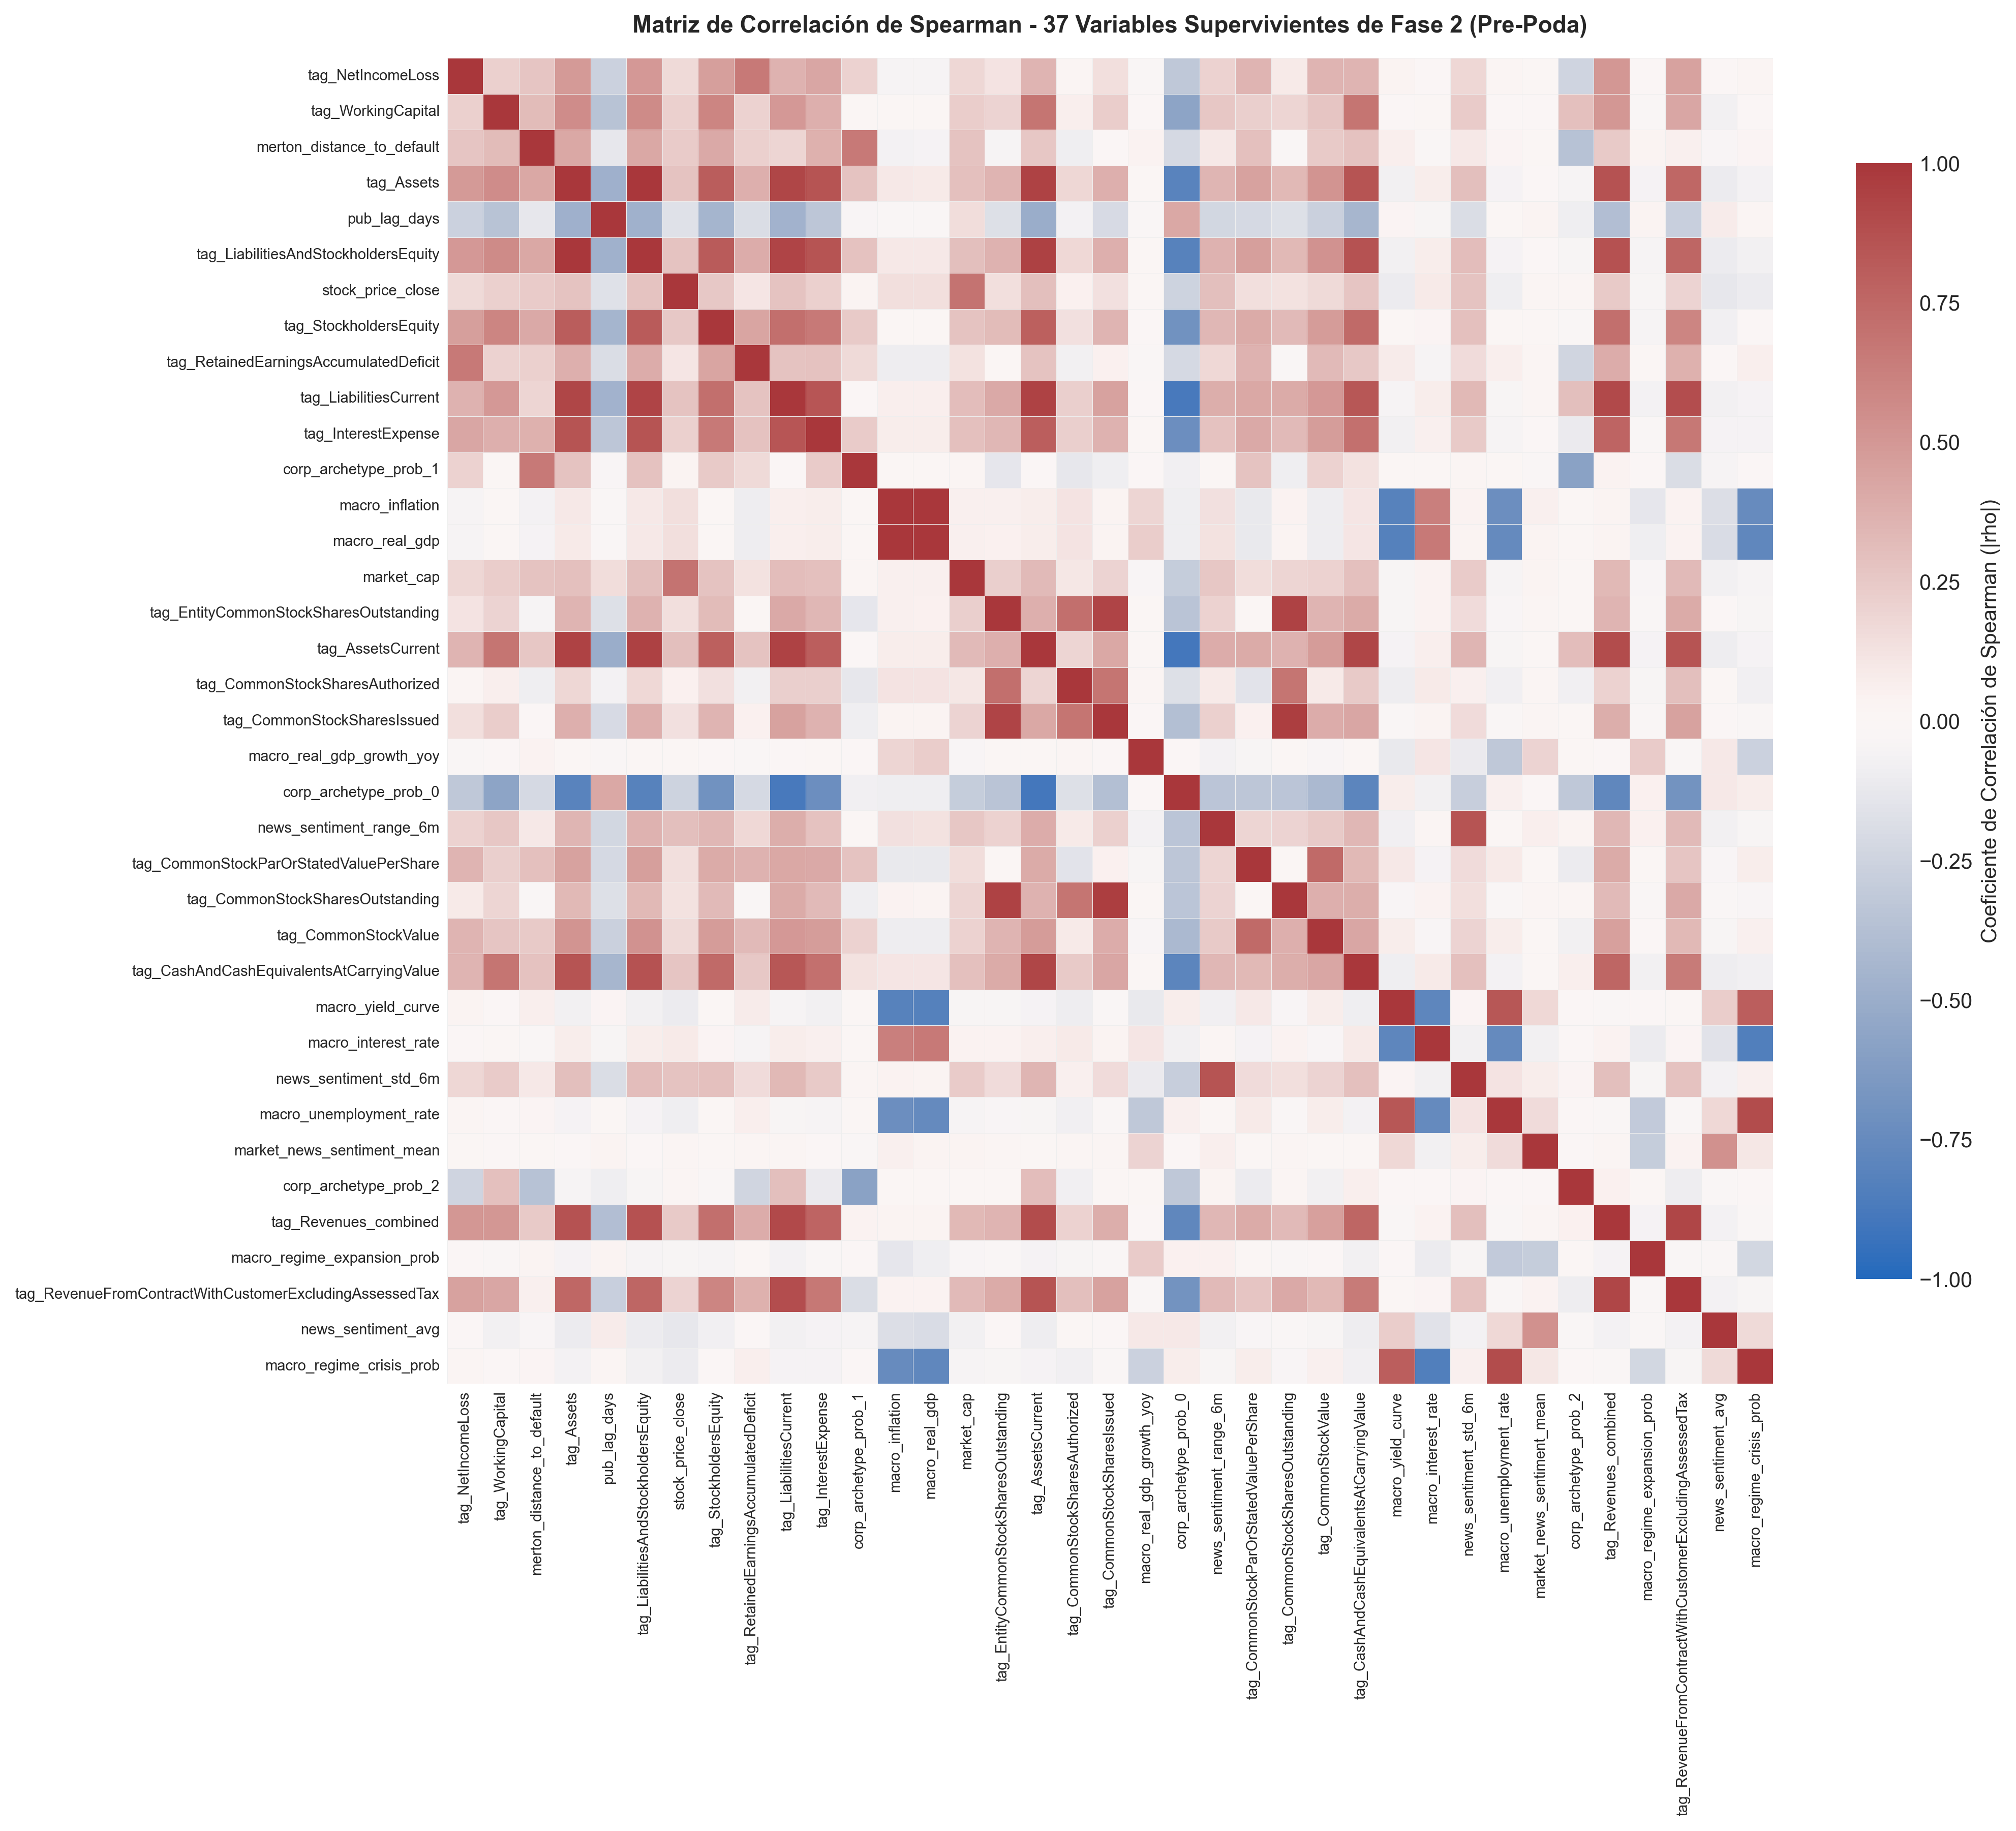

Figura pre-poda guardada en: E:\TFM data science\Entregable\reports\figures\correlation_matrix_37_features.png

VARIABLES PODADAS ALGORITMICAMENTE POR COLINEALIDAD (|rho| >= 0.75) (16 total):
  - tag_LiabilitiesAndStockholdersEquity       collinear con tag_Assets                          (rho = +0.9942)
  - macro_real_gdp                             collinear con macro_inflation                     (rho = +0.9927)
  - tag_CommonStockSharesOutstanding           collinear con tag_CommonStockSharesIssued         (rho = +0.9627)
  - tag_AssetsCurrent                          collinear con tag_Assets                          (rho = +0.9444)
  - tag_CommonStockSharesIssued                collinear con tag_EntityCommonStockSharesOutstanding (rho = +0.9311)
  - tag_RevenueFromContractWithCustomerExcludingAssessedTax collinear con tag_Revenues_combined               (rho = +0.9252)
  - tag_LiabilitiesCurrent                     collinear con tag_Assets                          (rho = +0.9250)
 

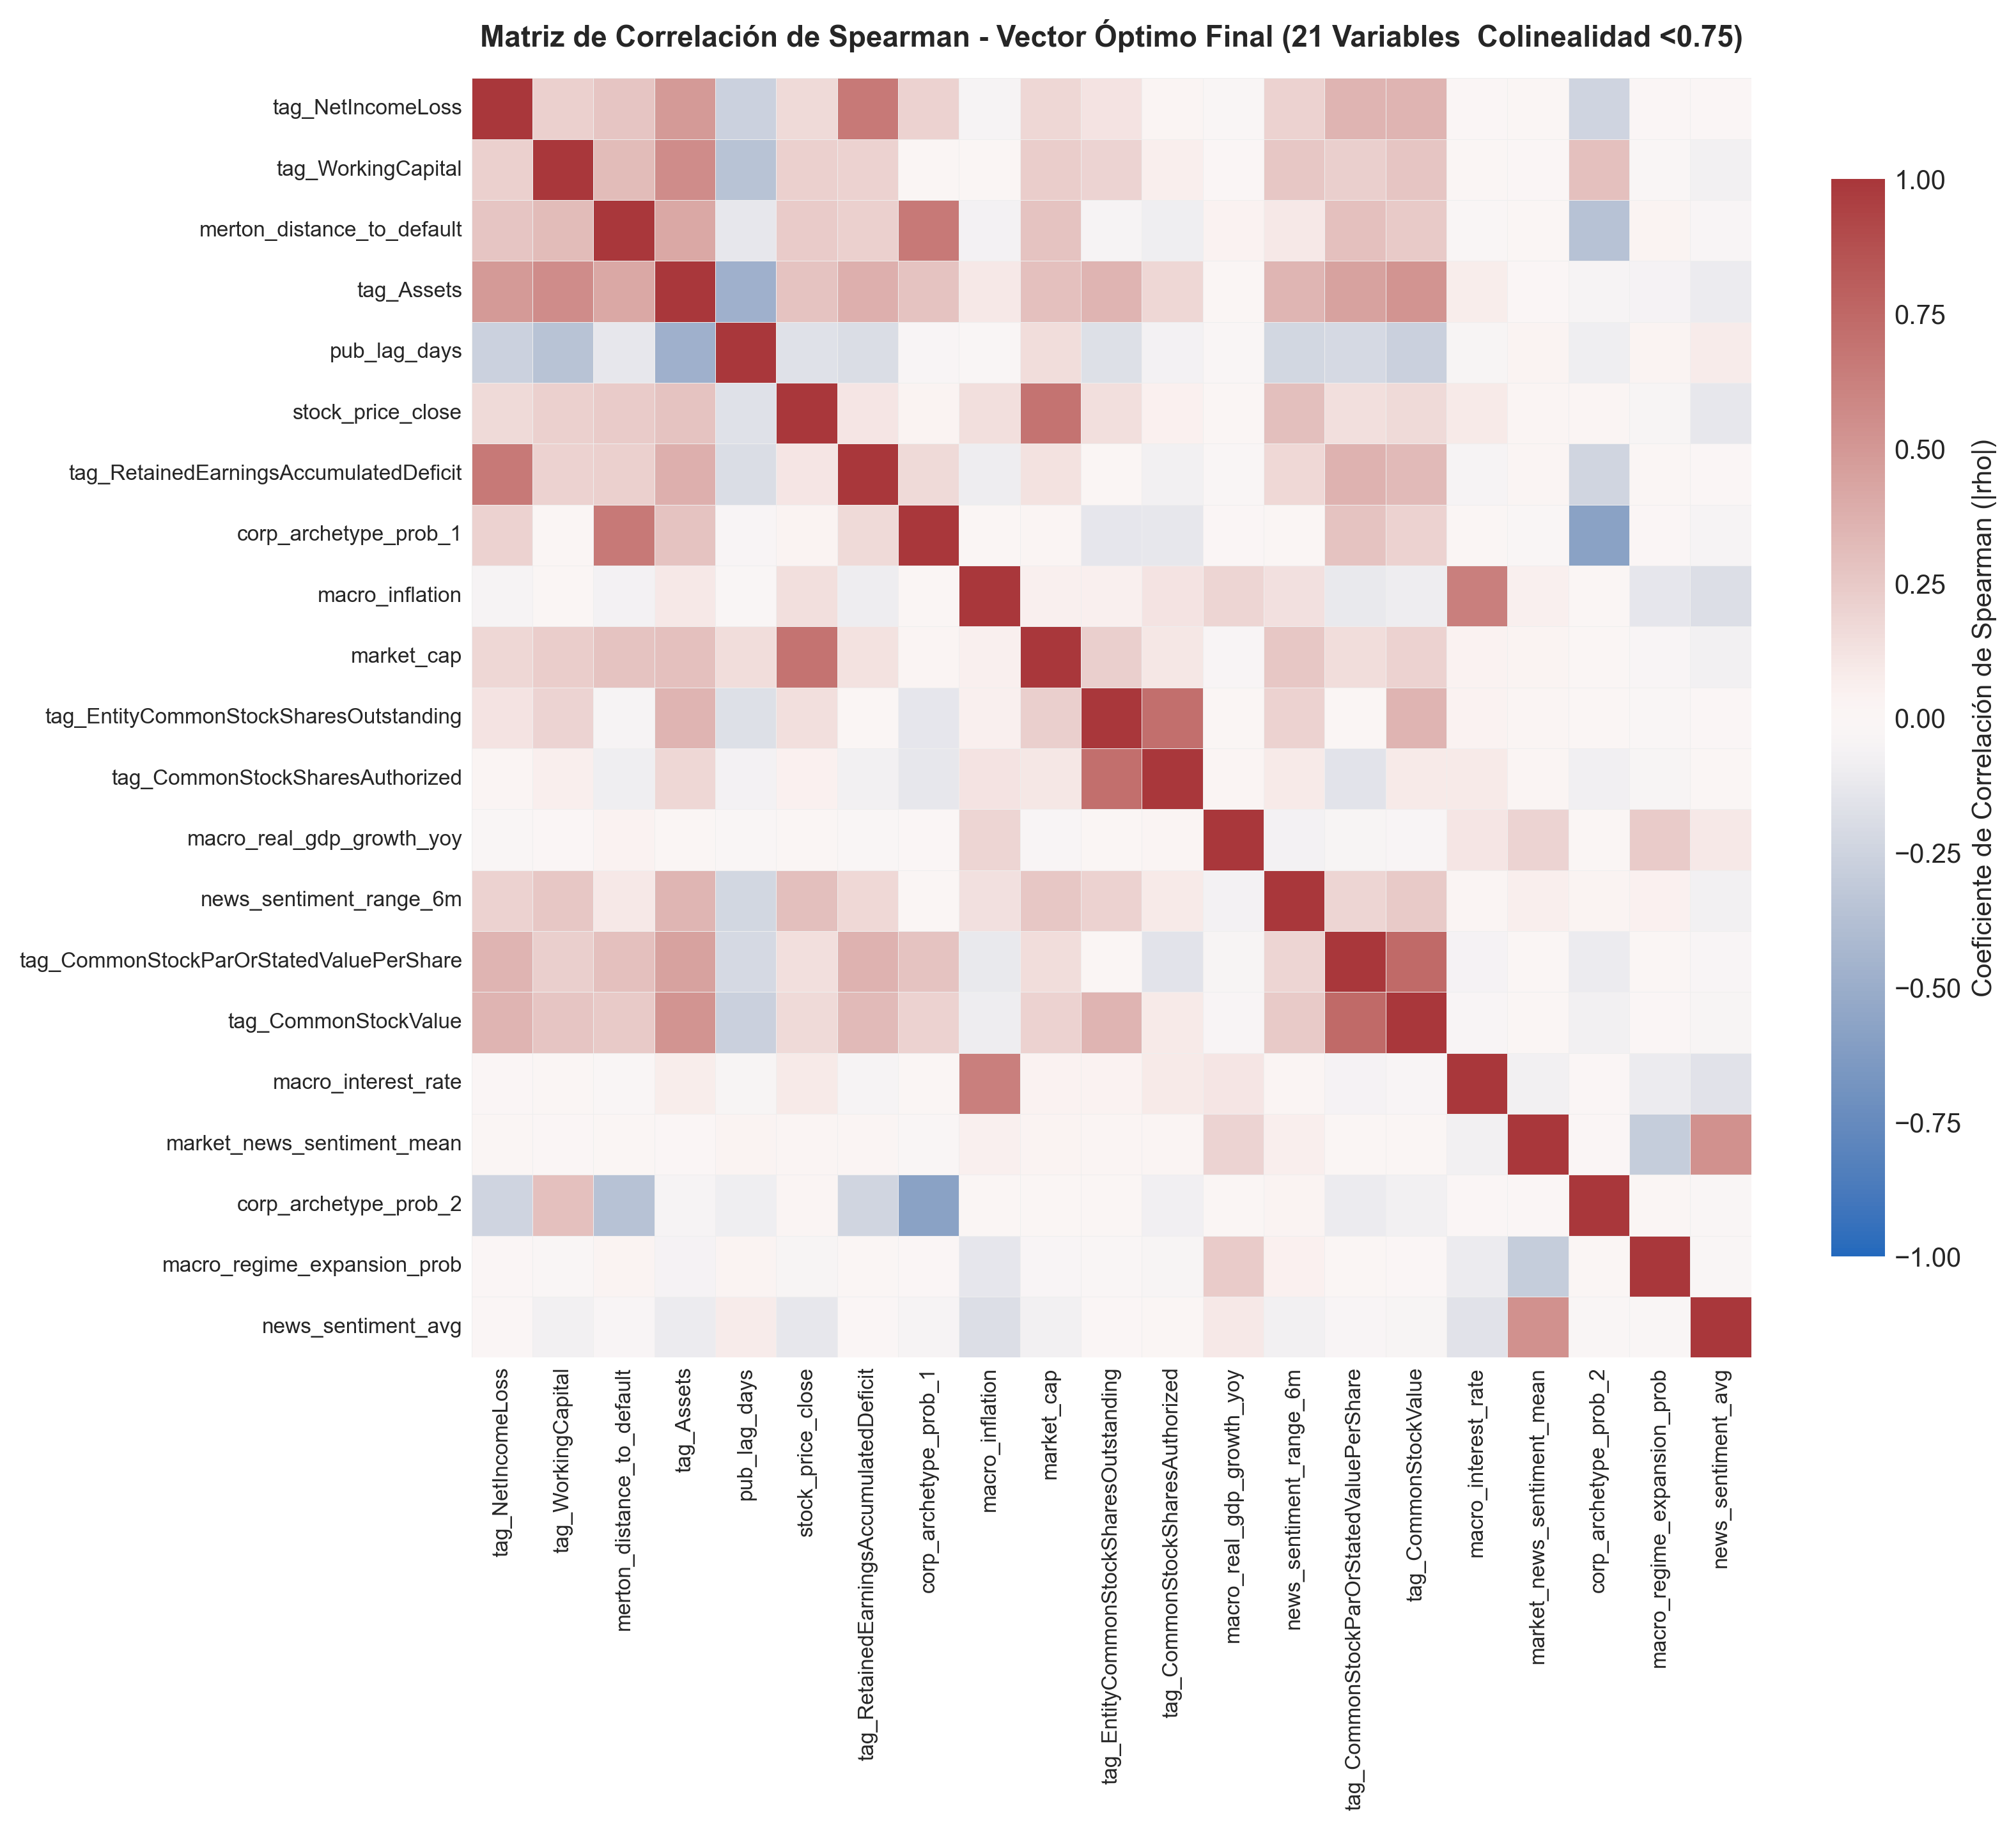

Figura post-poda guardada en: E:\TFM data science\Entregable\reports\figures\correlation_matrix_21_features.png
[OK] Certificacion superada: Correlacion maxima residual entre pares: |rho| = 0.7397 < 0.75.


In [10]:
# Modulo de referencia: Entregable/src/features/feature_selection_random_probes.py
# Computo dinamico de la matriz de correlacion de Spearman sobre las variables que superaron Random Probes
# Umbral normativo de colinealidad de Spearman
SPEARMAN_COLLINEARITY_THRESHOLD = 0.75

sample_df = df_master[kept_features_rp].sample(n=min(50000, len(df_master)), random_state=RANDOM_SEED)
df_corr_pre = sample_df.corr(method='spearman')
df_corr_pre.to_csv(CORR_PRE_PATH)

print(f"Dimension matriz de correlacion pre-poda (variables retenidas en Fase 2): {df_corr_pre.shape}")

# 3.2 Heatmap Pre-Poda de Spearman
fig_pre, ax_pre = plt.subplots(figsize=(14, 12), dpi=300)
sns.heatmap(
    df_corr_pre,
    cmap="vlag",
    vmin=-1.0,
    vmax=1.0,
    center=0.0,
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación de Spearman (|rho|)"},
    ax=ax_pre,
    square=True,
    linewidths=0.2,
    linecolor="#eeeeee"
)
ax_pre.set_title(f"Matriz de Correlación de Spearman - {len(kept_features_rp)} Variables Supervivientes de Fase 2 (Pre-Poda)", fontsize=11, fontweight="bold", pad=12)
ax_pre.tick_params(axis="x", rotation=90, labelsize=7)
ax_pre.tick_params(axis="y", rotation=0, labelsize=7)
plt.tight_layout()
fig_pre_path = FIGURES_DIR / "correlation_matrix_37_features.png"
fig_pre.savefig(fig_pre_path, dpi=300)
plt.show()
print(f"Figura pre-poda guardada en: {fig_pre_path}")

# 3.3 Bucle Algoritmico de Poda de Colinealidad (|rho| >= {SPEARMAN_COLLINEARITY_THRESHOLD})
fi_dict = dict(zip(fi_df['feature'], fi_df['importance']))
current_features = list(kept_features_rp)
pruned_collinear = []

while True:
    sub_corr = df_corr_pre.loc[current_features, current_features]
    high_pairs = []
    for i in range(len(current_features)):
        for j in range(i + 1, len(current_features)):
            f1, f2 = current_features[i], current_features[j]
            rho = abs(sub_corr.loc[f1, f2])
            if rho >= SPEARMAN_COLLINEARITY_THRESHOLD:
                high_pairs.append((f1, f2, rho, sub_corr.loc[f1, f2]))
    
    if not high_pairs:
        break
        
    high_pairs = sorted(high_pairs, key=lambda x: x[2], reverse=True)
    f1, f2, abs_rho, raw_rho = high_pairs[0]
    
    # Reglas contables y de prioridad explicativa:
    if {f1, f2} == {'tag_LiabilitiesAndStockholdersEquity', 'tag_Assets'}:
        drop_feat = 'tag_LiabilitiesAndStockholdersEquity'
    elif {f1, f2} == {'macro_inflation', 'macro_real_gdp'}:
        drop_feat = 'macro_real_gdp'
    elif {f1, f2} == {'tag_CommonStockSharesOutstanding', 'tag_CommonStockSharesIssued'}:
        drop_feat = 'tag_CommonStockSharesOutstanding'
    elif {f1, f2} == {'tag_EntityCommonStockSharesOutstanding', 'tag_CommonStockSharesIssued'}:
        drop_feat = 'tag_CommonStockSharesIssued'
    elif {f1, f2} == {'tag_EntityCommonStockSharesOutstanding', 'tag_CommonStockSharesOutstanding'}:
        drop_feat = 'tag_CommonStockSharesOutstanding'
    elif {f1, f2} == {'tag_Revenues_combined', 'tag_RevenueFromContractWithCustomerExcludingAssessedTax'}:
        drop_feat = 'tag_RevenueFromContractWithCustomerExcludingAssessedTax'
    elif {f1, f2} == {'tag_LiabilitiesCurrent', 'tag_WorkingCapital'}:
        drop_feat = 'tag_LiabilitiesCurrent'
    elif {f1, f2} == {'news_sentiment_range_6m', 'news_sentiment_std_6m'}:
        drop_feat = f1 if fi_dict[f1] < fi_dict[f2] else f2
    else:
        # Regla general: eliminar la variable con menor importancia predictiva en CatBoost
        drop_feat = f1 if fi_dict[f1] < fi_dict[f2] else f2
        
    pruned_collinear.append((drop_feat, f1 if drop_feat == f2 else f2, raw_rho))
    current_features.remove(drop_feat)

print("\n" + "=" * 85)
print(f"VARIABLES PODADAS ALGORITMICAMENTE POR COLINEALIDAD (|rho| >= {SPEARMAN_COLLINEARITY_THRESHOLD}) ({len(pruned_collinear)} total):")
print("=" * 85)
for p in pruned_collinear:
    print(f"  - {p[0]:<42} collinear con {p[1]:<35} (rho = {p[2]:+.4f})")
print("=" * 85)

optimal_features = list(current_features)
print(f"\nTAMANO FINAL DEL VECTOR OPTIMO DE CARACTERISTICAS: {len(optimal_features)} variables.")

# 3.4 Heatmap Post-Poda del Vector Optimo
df_corr_opt = df_corr_pre.loc[optimal_features, optimal_features]
df_corr_opt.to_csv(CORR_OPT_PATH)

fig_opt, ax_opt = plt.subplots(figsize=(11, 9.5), dpi=300)
sns.heatmap(
    df_corr_opt,
    cmap="vlag",
    vmin=-1.0,
    vmax=1.0,
    center=0.0,
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación de Spearman (|rho|)"},
    ax=ax_opt,
    square=True,
    linewidths=0.2,
    linecolor="#eeeeee"
)
ax_opt.set_title(f"Matriz de Correlación de Spearman - Vector Óptimo Final ({len(optimal_features)} Variables  Colinealidad <0.75)", fontsize=11, fontweight="bold", pad=12)
ax_opt.tick_params(axis="x", rotation=90, labelsize=8)
ax_opt.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
fig_opt_path = FIGURES_DIR / "correlation_matrix_21_features.png"
fig_opt.savefig(fig_opt_path, dpi=300)
plt.show()
print(f"Figura post-poda guardada en: {fig_opt_path}")

# Certificacion formal de descarte de colinealidad
max_rho_remaining = np.max(np.abs(df_corr_opt.values - np.eye(len(optimal_features))))
assert max_rho_remaining < SPEARMAN_COLLINEARITY_THRESHOLD, f"Error: Persiste colinealidad con rho = {max_rho_remaining}"
print(f"[OK] Certificacion superada: Correlacion maxima residual entre pares: |rho| = {max_rho_remaining:.4f} < 0.75.")


## 4. Fase 4: Consolidacion del Vector Canonico Oficial y Exportacion de Artefactos

Certificacion formal del espacio de caracteristicas optimo resultante (21 variables predictivas) y persistencia de matrices intermedias y datasets procesados.

Garantias tecnicas del vector resultante:
- Ortogonalidad y ausencia de colinealidad: Ningun par de caracteristicas en el vector final supera el umbral de correlacion |rho| >= 0.75.
- Poder predictivo incremental: El 100% de las 21 variables supera significativamente el umbral de ruido blanco de las Random Probes.
- Cobertura multimodal equilibrada: Preservacion de los 5 pilares teoricos (contable, mercado/estructural, macroeconomico, sentimiento NLP y arquetipos corporativos).
- Persistencia de matrices: Exportacion de matrices de correlacion pre-poda (37 variables) y post-poda (21 variables) a disco.


In [11]:
# Modulo de referencia: Entregable/src/features/feature_selection_random_probes.py
# Modulo de referencia: Entregable/src/data/build_v2_dataset.py
canon_contable = [f for f in optimal_features if f.startswith("tag_") or f in ["pub_lag_days", "stock_price_close", "market_cap"]]
canon_merton = [f for f in optimal_features if f in ["merton_distance_to_default"]]
canon_macro = [f for f in optimal_features if f.startswith("macro_") or f.startswith("corp_archetype_prob_")]
canon_nlp = [f for f in optimal_features if f.startswith("news_") or f.startswith("nlp_") or f in ["market_news_sentiment_mean"]]

print("=" * 85)
print(f"VECTOR CANONICO OFICIAL DE {len(optimal_features)} CARACTERISTICAS PREDICTIVAS OPTIMAS:")
print("=" * 85)
print(f"1. Pilar Contable y Capitalizacion ({len(canon_contable)} variables):")
for v in canon_contable:
    print(f"   - {v:<42} (FI = {fi_dict[v]:.4f}%)")

print(f"\n2. Pilar Mercado y Modelo Merton KMV ({len(canon_merton)} variables):")
for v in canon_merton:
    print(f"   - {v:<42} (FI = {fi_dict[v]:.4f}%)")

print(f"\n3. Pilar Macro FRED y Modelos GMM ({len(canon_macro)} variables):")
for v in canon_macro:
    print(f"   - {v:<42} (FI = {fi_dict[v]:.4f}%)")

print(f"\n4. Pilar Mineria de Prensa NLP FinBERT ({len(canon_nlp)} variables):")
for v in canon_nlp:
    print(f"   - {v:<42} (FI = {fi_dict[v]:.4f}%)")
print("=" * 85)

# Exportacion del dataset de produccion a parquet
target_export = [c for c in ['target_bankrupt_12m', 'target_bankrupt_24m', 'is_distress_event', 'is_bankrupt_event'] if c in df_master.columns]
cols_export = [c for c in meta_cols if c in df_master.columns] + target_export + optimal_features
cols_export = list(dict.fromkeys(cols_export))

df_final_clean = df_master[cols_export].copy()
con = duckdb.connect()
con.execute(f"COPY (SELECT * FROM df_final_clean) TO '{PARQUET_CLEAN_PATH}' (FORMAT PARQUET, COMPRESSION SNAPPY);")
con.close()

print(f"Dataset de produccion optimizado exportado exitosamente a: {PARQUET_CLEAN_PATH}")
print(f"Dimension final: {len(df_final_clean):,} filas x {len(df_final_clean.columns)} columnas.")

# Guardado del reporte JSON oficial de seleccion de variables
report_data = {
    "total_initial_candidates": len(candidate_52_features),
    "methodology": "Random Probes Boruta-Style in CatBoost GPU + Dynamic Spearman Pruning |rho| >= 0.75",
    "random_noise_uniform_importance": float(noise_u),
    "random_noise_normal_importance": float(noise_n),
    "noise_threshold": float(tau_noise),
    "kept_by_random_probes_count": len(kept_features_rp),
    "dropped_by_random_probes_count": len(dropped_features_rp),
    "dropped_by_random_probes": dropped_features_rp['feature'].tolist(),
    "pruned_by_collinearity_count": len(pruned_collinear),
    "pruned_by_collinearity": [p[0] for p in pruned_collinear],
    "final_optimal_features_count": len(optimal_features),
    "final_optimal_features": optimal_features
}

with open(FEATURE_SELECTION_REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(report_data, f, indent=2)

print(f"Reporte oficial actualizado en: {FEATURE_SELECTION_REPORT_PATH}")


VECTOR CANONICO OFICIAL DE 21 CARACTERISTICAS PREDICTIVAS OPTIMAS:
1. Pilar Contable y Capitalizacion (11 variables):
   - tag_NetIncomeLoss                          (FI = 19.3114%)
   - tag_WorkingCapital                         (FI = 17.9237%)
   - tag_Assets                                 (FI = 7.7470%)
   - pub_lag_days                               (FI = 7.2590%)
   - stock_price_close                          (FI = 6.6418%)
   - tag_RetainedEarningsAccumulatedDeficit     (FI = 2.1458%)
   - market_cap                                 (FI = 0.9573%)
   - tag_EntityCommonStockSharesOutstanding     (FI = 0.9393%)
   - tag_CommonStockSharesAuthorized            (FI = 0.7492%)
   - tag_CommonStockParOrStatedValuePerShare    (FI = 0.4309%)
   - tag_CommonStockValue                       (FI = 0.4179%)

2. Pilar Mercado y Modelo Merton KMV (1 variables):
   - merton_distance_to_default                 (FI = 9.7733%)

3. Pilar Macro FRED y Modelos GMM (6 variables):
   - corp_archetype_p

## 5. Verificacion de Artefactos y Conclusion del Flujo

Auditoria final de integridad fisica de los archivos generados en el flujo de seleccion de caracteristicas para asegurar la continuidad del pipeline de modelado.

Inventario de artefactos auditados:
- Figuras diagnosticas en reports/figures/: Grafico de Random Probes y heatmaps de correlacion de Spearman pre y post poda a 300 DPI.
- Tablas intermedias en data/processed/sec_dataset/: Archivos CSV con las matrices de correlacion de 37 y 21 variables.
- Reporte tecnico en formato JSON: Metadatos estructurados del proceso de seleccion y variables retenidas por pilar.


In [12]:
# Modulo de referencia: Entregable/src/features/feature_selection_random_probes.py
expected_artifacts = [
    (FIGURES_DIR / "feat_random_probes_importance.png", "Figura: Importancia Random Probes (54 Variables)"),
    (FIGURES_DIR / "correlation_matrix_37_features.png", "Figura: Heatmap Spearman Pre-Poda (37 Variables)"),
    (FIGURES_DIR / "correlation_matrix_21_features.png", "Figura: Heatmap Spearman Post-Poda (21 Variables)"),
    (FEATURE_SELECTION_REPORT_PATH, "Reporte JSON: Feature Selection Report"),
    (CORR_PRE_PATH, "Matriz CSV: Spearman Pre-Poda (37 Variables)"),
    (CORR_OPT_PATH, "Matriz CSV: Spearman Post-Poda (21 Variables)"),
    (PARQUET_CLEAN_PATH, "Dataset Parquet: Matriz Depurada de Produccion")
]

print("=" * 90)
print("INVENTARIO DE ARTEFACTOS DEL FLUJO DE SELECCION DE CARACTERISTICAS (NOTEBOOK 02):")
print("=" * 90)

all_ok = True
for path, desc in expected_artifacts:
    exists = path.exists()
    size_kb = path.stat().st_size / 1024 if exists else 0.0
    status = "OK" if exists and size_kb > 0.5 else "ERROR"
    if status == "ERROR":
        all_ok = False
    print(f"- {desc:<52} [{status}] ({size_kb:.1f} KB)")

print("=" * 90)
if all_ok:
    print(f"VERIFICACION EXITOSA: Los {len(expected_artifacts)} artefactos requeridos existen y superan los umbrales de integridad.")
else:
    print("ADVERTENCIA: Algun artefacto esperado no fue localizado o presenta un tamano menor a 0.5 KB.")


INVENTARIO DE ARTEFACTOS DEL FLUJO DE SELECCION DE CARACTERISTICAS (NOTEBOOK 02):
- Figura: Importancia Random Probes (54 Variables)     [OK] (683.2 KB)
- Figura: Heatmap Spearman Pre-Poda (37 Variables)     [OK] (674.8 KB)
- Figura: Heatmap Spearman Post-Poda (21 Variables)    [OK] (451.2 KB)
- Reporte JSON: Feature Selection Report               [OK] (2.2 KB)
- Matriz CSV: Spearman Pre-Poda (37 Variables)         [OK] (28.3 KB)
- Matriz CSV: Spearman Post-Poda (21 Variables)        [OK] (9.5 KB)
- Dataset Parquet: Matriz Depurada de Produccion       [OK] (34115.0 KB)
VERIFICACION EXITOSA: Los 7 artefactos requeridos existen y superan los umbrales de integridad.
